In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
import pickle
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
df = pd.read_csv("Pakistani_Diabetes_Dataset.csv")


In [3]:
df.columns = df.columns.str.strip()

In [4]:
df.columns

Index(['Age', 'Gender', 'Rgn', 'wt', 'BMI', 'wst', 'sys', 'dia', 'his', 'A1c',
       'B.S.R', 'vision', 'Exr', 'dipsia', 'uria', 'Dur', 'neph', 'HDL',
       'Outcome'],
      dtype='object')

In [5]:
df.head()

,Age,Gender,Rgn,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Age      912 non-null    float64
 1   Gender   912 non-null    int64  
 2   Rgn      912 non-null    int64  
 3   wt       912 non-null    float64
 4   BMI      912 non-null    float64
 5   wst      912 non-null    float64
 6   sys      912 non-null    int64  
 7   dia      912 non-null    int64  
 8   his      912 non-null    int64  
 9   A1c      912 non-null    float64
 10  B.S.R    912 non-null    int64  
 11  vision   912 non-null    int64  
 12  Exr      912 non-null    int64  
 13  dipsia   912 non-null    int64  
 14  uria     912 non-null    int64  
 15  Dur      912 non-null    float64
 16  neph     912 non-null    int64  
 17  HDL      912 non-null    int64  
 18  Outcome  912 non-null    int64  
dtypes: float64(6), int64(13)
memory usage: 135.5 KB


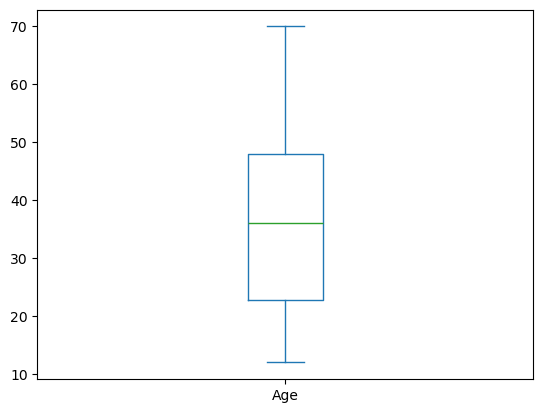

In [7]:
df['Age'].plot(kind='box');

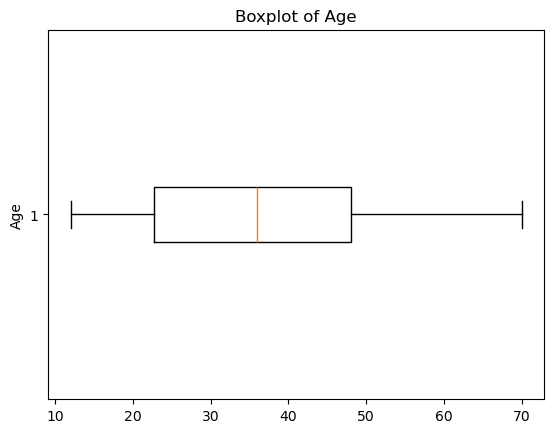

In [8]:
plt.boxplot(df['Age'] , vert=False)
plt.ylabel('Age')
plt.title('Boxplot of Age')
plt.show()

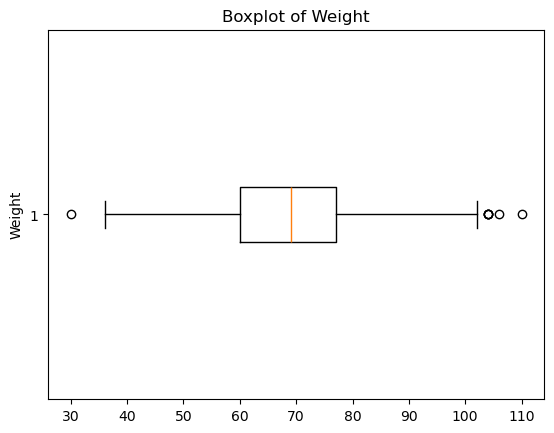

In [9]:
plt.boxplot(df['wt'] , vert=False)
plt.ylabel('Weight')
plt.title('Boxplot of Weight')
plt.show()

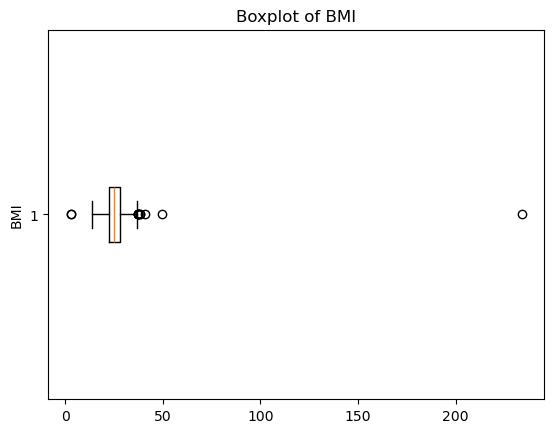

In [10]:
plt.boxplot(df['BMI'] , vert=False)
plt.ylabel('BMI')
plt.title('Boxplot of BMI')
plt.show()
BMI_LOWER_CAP = 12
BMI_UPPER_CAP = 90


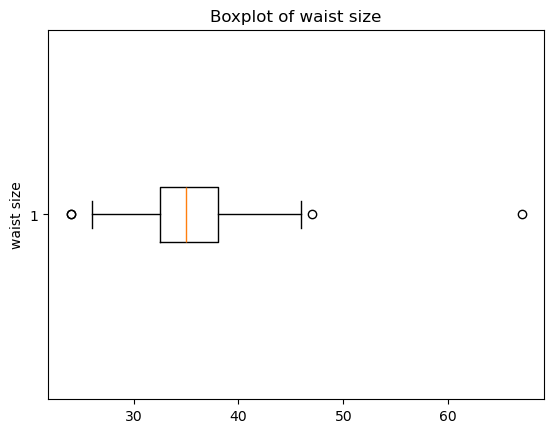

In [11]:
plt.boxplot(df['wst'] , vert=False)
plt.ylabel('waist size')
plt.title('Boxplot of waist size')
plt.show()
WAIST_LOWER_CAP = 20
WAIST_UPPER_CAP = 90



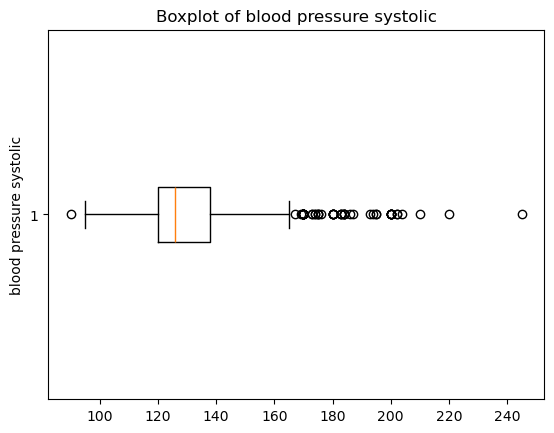

In [12]:
plt.boxplot(df['sys'] , vert=False)
plt.ylabel('blood pressure systolic')
plt.title('Boxplot of blood pressure systolic')
plt.show()

SYS_LOWER_CAP = 60
SYS_LOWER_CAP = 250


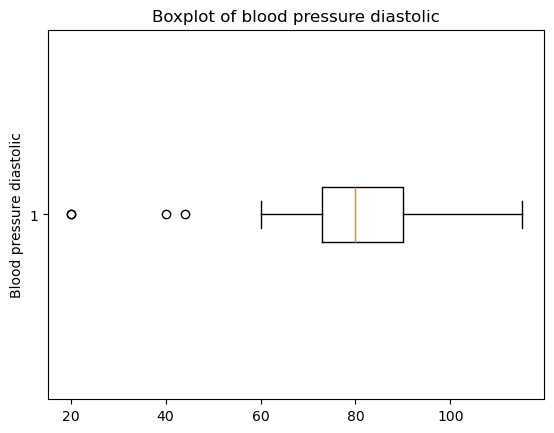

In [13]:
plt.boxplot(df['dia'] , vert=False)
plt.ylabel('Blood pressure diastolic')
plt.title('Boxplot of blood pressure diastolic')
plt.show()
DIA_LOWER_CAP = 40
DIA_UPPER_CAP = 150


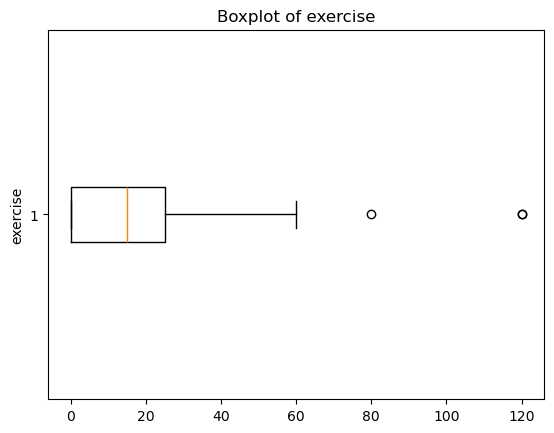

In [14]:
plt.boxplot(df['Exr'] , vert=False)
plt.ylabel('exercise')
plt.title('Boxplot of exercise')
plt.show()
EXERCISE_UPPER_CAP = 300

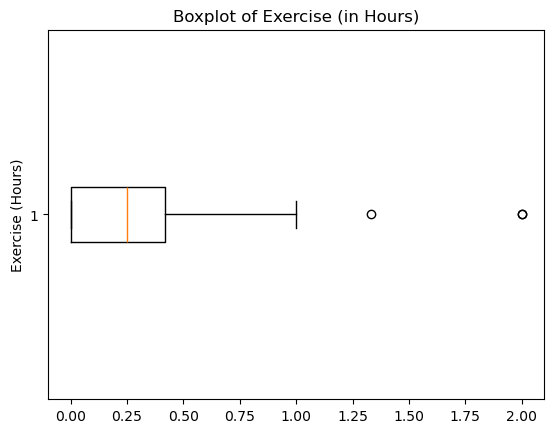

In [15]:
df['Exr_hours'] = df['Exr'] / 60
EXERCISE_UPPER_CAP_HOURS = 5
plt.boxplot(df['Exr_hours'], vert=False) 
plt.ylabel('Exercise (Hours)')
plt.title('Boxplot of Exercise (in Hours)')
plt.show()

In [16]:
df['BMI_wst'] = df['BMI'] * df['wst']
df['bp_ratio'] = df['sys'] / df['dia']


In [17]:
num_cols = ['wt', 'BMI', 'wst', 'sys', 'dia', 'HDL', 'Exr_hours']

In [18]:
cat_cols = ['Gender', 'Rgn', 'his', 'dipsia', 'uria']

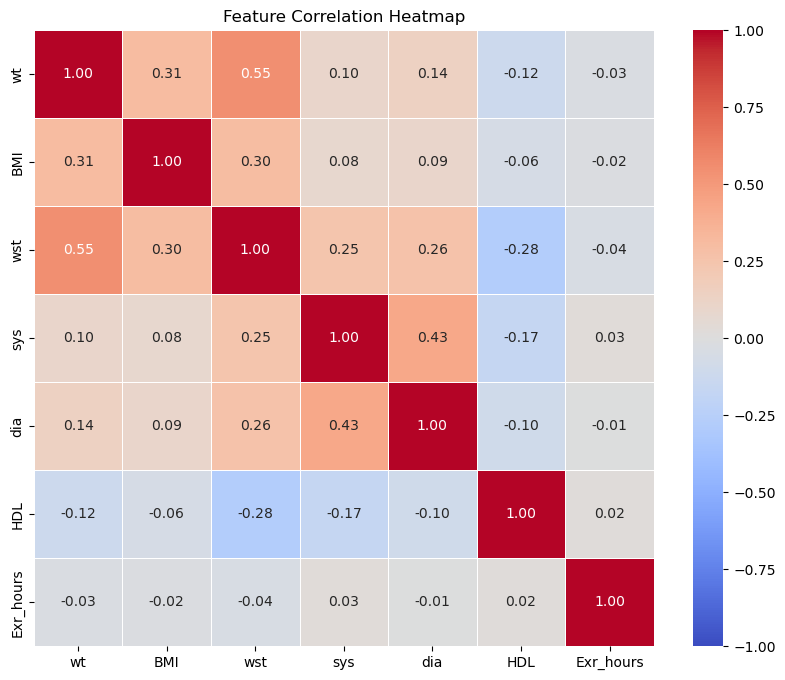

In [19]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
for col in cat_cols:
    print(f"--- Unique values in {col} ---")

    print(df[col].value_counts(dropna=False)) 
    print("\n")

--- Unique values in Gender ---
Gender
1    503
0    409
Name: count, dtype: int64


--- Unique values in Rgn ---
Rgn
0    648
1    264
Name: count, dtype: int64


--- Unique values in his ---
his
1    534
0    378
Name: count, dtype: int64


--- Unique values in dipsia ---
dipsia
0    566
1    346
Name: count, dtype: int64


--- Unique values in uria ---
uria
0    613
1    299
Name: count, dtype: int64




In [21]:
# 1. Check exactly how many outcomes are missing before you drop anything
missing_outcomes = df['Outcome'].isnull().sum()
print(f"Missing Outcomes: {missing_outcomes}")

# 2. Drop ONLY the rows where the 'Outcome' specifically is missing
# (This keeps a patient who has an Outcome but might just be missing a blood pressure reading)
df = df.dropna(subset=['Outcome'])

print(f"Remaining clean rows for modeling: {len(df)}")

Missing Outcomes: 0
Remaining clean rows for modeling: 912


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        912 non-null    float64
 1   Gender     912 non-null    int64  
 2   Rgn        912 non-null    int64  
 3   wt         912 non-null    float64
 4   BMI        912 non-null    float64
 5   wst        912 non-null    float64
 6   sys        912 non-null    int64  
 7   dia        912 non-null    int64  
 8   his        912 non-null    int64  
 9   A1c        912 non-null    float64
 10  B.S.R      912 non-null    int64  
 11  vision     912 non-null    int64  
 12  Exr        912 non-null    int64  
 13  dipsia     912 non-null    int64  
 14  uria       912 non-null    int64  
 15  Dur        912 non-null    float64
 16  neph       912 non-null    int64  
 17  HDL        912 non-null    int64  
 18  Outcome    912 non-null    int64  
 19  Exr_hours  912 non-null    float64
 20  BMI_wst   

In [23]:
df = df[df['wt'].between(30, 300)]
df = df[df['sys'].between(60, 250)]
df = df[df['dia'].between(40, 150)]
df = df[df['wst'].between(20, 90)]
df = df[df['BMI'].between(12, 90)]

In [24]:
features = [
    'Gender', 'Rgn', 'wt', 'BMI', 'wst',
    'sys', 'dia', 'his', 'dipsia', 
    'uria', 'HDL', 'Exr_hours'
]

In [25]:
X= df[features]
y= df["Outcome"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', 'passthrough', cat_cols)
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_processed,  dtype=torch.float32)
 
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values,       dtype=torch.float32).view(-1, 1)

In [30]:
actual_num_features = X_train_tensor.shape[1]
print("Num features:", actual_num_features)

Num features: 12


In [31]:
torch.manual_seed(71)
# np.random.seed(71)

In [32]:
model = nn.Sequential(
    nn.Linear(actual_num_features, 24),  # <--- Set to 13
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(24, 16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16, 1)
)

In [33]:
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [34]:
for epoch in range(1000):
        model.train()
        predictions = model(X_train_tensor)
        loss = loss_fn(predictions, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [35]:
model.eval()
with torch.no_grad():
    raw_logits = model(X_test_tensor)          # raw logits
 
    # FIX: Convert logits → probabilities with sigmoid BEFORE thresholding
    probs = torch.sigmoid(raw_logits)
    final_decisions = (probs >= 0.5).float()
 
    accuracy = accuracy_score(y_test_tensor.numpy(), final_decisions.numpy())
    print(f"Final Model Accuracy: {accuracy * 100:.2f}%")
 

Final Model Accuracy: 93.96%


In [36]:
# Training accuracy
model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(X_train_tensor))
    train_preds = (train_probs >= 0.5).float()
    train_acc = accuracy_score(y_train_tensor.numpy(), train_preds.numpy())
    print(f"Train Accuracy: {train_acc * 100:.2f}%")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 95.86%
Test Accuracy: 93.96%



Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94        86
         1.0       0.94      0.95      0.94        96

    accuracy                           0.94       182
   macro avg       0.94      0.94      0.94       182
weighted avg       0.94      0.94      0.94       182



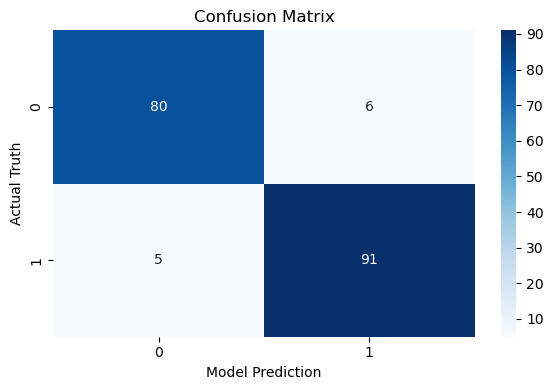

In [37]:
print("\nClassification Report:")
print(classification_report(y_test_tensor.numpy(), final_decisions.numpy()))
 
cm = confusion_matrix(y_test_tensor.numpy(), final_decisions.numpy())
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Train the simple baseline model
baseline_model = LogisticRegression()
baseline_model.fit(X_train_processed, y_train)

# 2. Get the baseline accuracy
y_pred_baseline = baseline_model.predict(X_test_processed)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

print(f"Neural Network Accuracy: 95.03%")
print(f"Logistic Regression Baseline: {baseline_acc * 100:.2f}%")

Neural Network Accuracy: 95.03%
Logistic Regression Baseline: 91.21%


In [39]:
from sklearn.inspection import permutation_importance
# or simply:
import numpy as np

# Check feature correlations with target
correlations = df[features + ['Outcome']].corr()['Outcome'].abs().sort_values(ascending=False)
print(correlations)

Outcome      1.000000
dipsia       0.608053
wst          0.552638
uria         0.539821
HDL          0.438279
BMI          0.427961
sys          0.367216
Gender       0.320239
dia          0.275118
wt           0.173655
his          0.134396
Exr_hours    0.073562
Rgn          0.002238
Name: Outcome, dtype: float64


In [40]:
print(actual_num_features)
print(X_train.shape)

12
(725, 12)


In [41]:
print(features)
print(actual_num_features)

['Gender', 'Rgn', 'wt', 'BMI', 'wst', 'sys', 'dia', 'his', 'dipsia', 'uria', 'HDL', 'Exr_hours']
12


In [42]:
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).numpy()
    
roc = roc_auc_score(y_test_tensor.numpy(), probs)
print(f"ROC-AUC Score: {roc:.4f}")

ROC-AUC Score: 0.9730


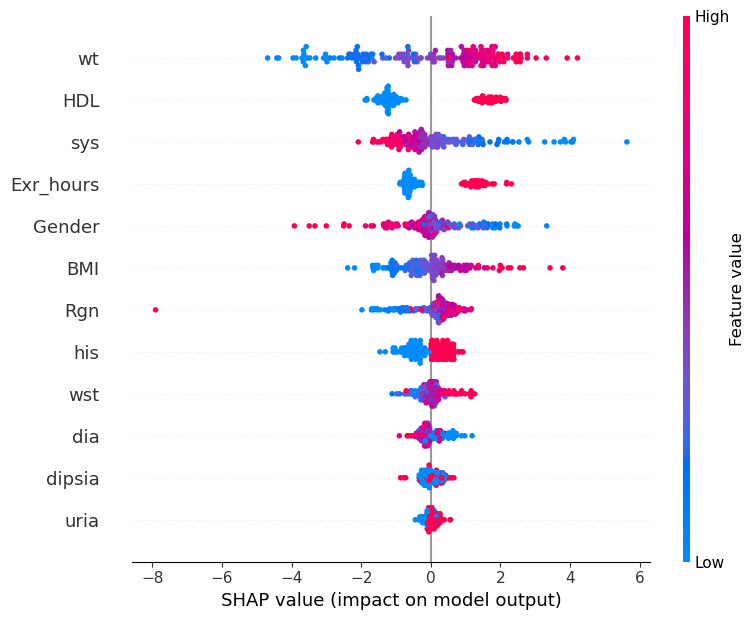

In [43]:
import shap  # <--- Add this line
# Option 2: Better approach - take a random sample of 100 instances
# (Useful if your data is sorted by class)
indices = torch.randperm(len(X_train_tensor))[:100]
background_data_tensor = X_train_tensor[indices]

# Now you can initialize the explainer safely
explainer = shap.DeepExplainer(model, background_data_tensor)

# ... and continue with the rest of the code
shap_values = explainer.shap_values(X_test_tensor)
shap_values_fixed = shap_values.squeeze(-1)
shap.summary_plot(shap_values_fixed, X_test_tensor.numpy(), feature_names=features)

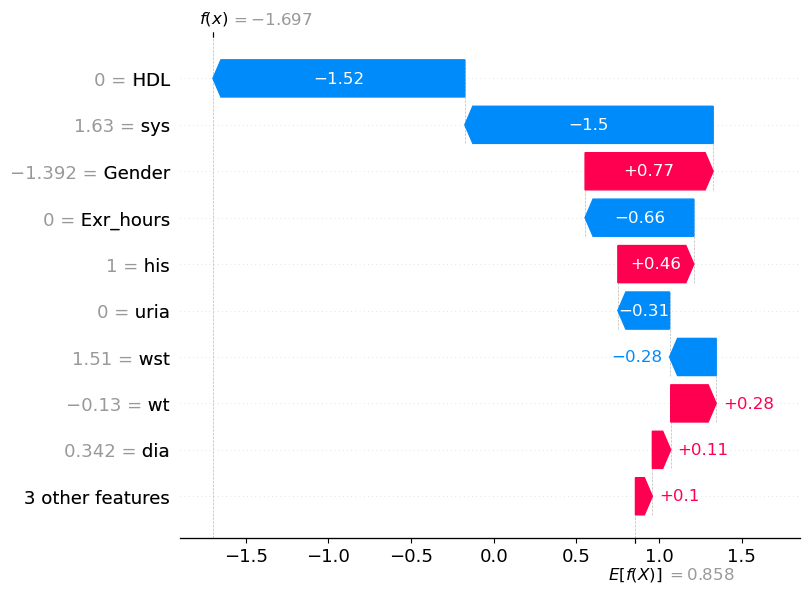

In [44]:
# Single patient explanation
shap.waterfall_plot(shap.Explanation(
    values=shap_values_fixed[0],
    base_values=explainer.expected_value[0],
    data=X_test_tensor[0].numpy(),
    feature_names=features
))

In [99]:
torch.save(model.state_dict(), 'diabetes_model.pth')



In [101]:

import pickle
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)